## 1) Import libraries

In [1]:
pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 1.5 MB/s eta 0:03:50
   ---------------------------------------- 0.8/350.9 MB 1.5 MB/s eta 0:04:00
   ---------------------------------------- 1.3/350.9 MB 1.5 MB/s eta 0:03:50
   ---------------------------------------- 1.6/350.9 MB 1.6 MB/s eta 0:03:45
   ---------------------------------------- 1.8/350.9 MB 1.6 MB/s eta 0:03:39
   ---------------------------------------- 2.4/350.9 MB 1.6 MB/s eta 0:03:33
   ---------------------------------------- 2.6/350.9 MB 1.7 MB/s eta 0:03:30
   ---------------------------------------- 3.1/350.9 MB 1.7 MB/s eta 0:03:24
   ---------------------------------------- 3.7/350.9 MB 1.7 MB/s eta 0:03:20
   ---------------------------------------- 3.9/350.9 MB 1.8 MB/s eta 0:03:17
    --------------------------------------- 4.5/350.9 MB 1.8 MB/s eta 0:03:15


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Optional settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2) Load the dataset

In [3]:
file_path = "WHO_India_Cities_Air_Quality_2022_subset.xlsx"

# Load the main sheet
df = pd.read_excel(file_path, sheet_name="India_All_Rows")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (2265, 12)


,WHO Region,ISO3,WHO Country Name,City or Locality,Measurement Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Reference
0,South East Asia Region,IND,India,Adilabad,2016,32.0,63.0,19.0,59.615385,60.576923,55.769231,Central Pollution Control Board
1,South East Asia Region,IND,India,Adilabad,2017,31.0,65.0,20.0,87.500000,87.500000,87.500000,Central Pollution Control Board
2,South East Asia Region,IND,India,Adilabad,2018,33.0,69.0,23.0,82.692308,82.692308,82.692308,Central Pollution Control Board
3,South East Asia Region,IND,India,Adilabad,2019,45.0,74.0,25.0,86.538461,100.000000,100.000000,Central Pollution Control Board
4,South East Asia Region,IND,India,Adilabad District,2013,NaN,NaN,14.0,NaN,NaN,25.961538,Central Pollution Control Board


## 3) Understand the dataset

In [5]:
print("\n--- INFO ---")
print(df.info())


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   WHO Region                  2265 non-null   object 
 1   ISO3                        2265 non-null   object 
 2   WHO Country Name            2265 non-null   object 
 3   City or Locality            2265 non-null   object 
 4   Measurement Year            2265 non-null   int64  
 5   PM2.5 (μg/m3)               421 non-null    float64
 6   PM10 (μg/m3)                1197 non-null   float64
 7   NO2 (μg/m3)                 2131 non-null   float64
 8   PM25 temporal coverage (%)  441 non-null    float64
 9   PM10 temporal coverage (%)  1212 non-null   float64
 10  NO2 temporal coverage (%)   2184 non-null   float64
 11  Reference                   2265 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 212.5+ KB
None


In [6]:
print("\n--- FIRST 5 ROWS ---")
display(df.head())


--- FIRST 5 ROWS ---


,WHO Region,ISO3,WHO Country Name,City or Locality,Measurement Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Reference
0,South East Asia Region,IND,India,Adilabad,2016,32.0,63.0,19.0,59.615385,60.576923,55.769231,Central Pollution Control Board
1,South East Asia Region,IND,India,Adilabad,2017,31.0,65.0,20.0,87.500000,87.500000,87.500000,Central Pollution Control Board
2,South East Asia Region,IND,India,Adilabad,2018,33.0,69.0,23.0,82.692308,82.692308,82.692308,Central Pollution Control Board
3,South East Asia Region,IND,India,Adilabad,2019,45.0,74.0,25.0,86.538461,100.000000,100.000000,Central Pollution Control Board
4,South East Asia Region,IND,India,Adilabad District,2013,NaN,NaN,14.0,NaN,NaN,25.961538,Central Pollution Control Board


In [11]:
print("\n--- DESCRIBE ---")
display(df.describe())


--- DESCRIBE ---


,Measurement Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%)
count,2265.000000,421.000000,1197.00000,2131.000000,441.000000,1212.000000,2184.000000
mean,2015.241943,40.444798,98.32452,21.966096,72.796073,86.650289,83.685706
std,2.986085,20.200245,50.34706,12.711148,27.368950,18.209648,21.855401
min,2010.000000,7.000000,8.50000,2.000000,1.923077,6.730769,1.923077
25%,2013.000000,28.000000,63.00000,13.000000,53.846154,81.250000,76.923077
50%,2016.000000,36.000000,88.00000,19.000000,82.692308,94.230769,93.269231
75%,2018.000000,47.000000,119.00000,28.000000,98.076923,100.000000,100.000000
max,2019.000000,123.500000,322.00000,87.500000,100.000000,100.000000,100.000000


In [12]:
print("\n--- MISSING VALUES ---")
display(df.isnull().sum())


--- MISSING VALUES ---


WHO Region                       0
ISO3                             0
WHO Country Name                 0
City or Locality                 0
Measurement Year                 0
PM2.5 (μg/m3)                 1844
PM10 (μg/m3)                  1068
NO2 (μg/m3)                    134
PM25 temporal coverage (%)    1824
PM10 temporal coverage (%)    1053
NO2 temporal coverage (%)       81
Reference                        0
dtype: int64

## 4) Basic cleaning

In [13]:
# Remove duplicate rows
df = df.drop_duplicates()

# Strip column names
df.columns = df.columns.str.strip()

# Check column names
print("Columns:")
print(df.columns.tolist())

Columns:
['WHO Region', 'ISO3', 'WHO Country Name', 'City or Locality', 'Measurement Year', 'PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)', 'PM25 temporal coverage (%)', 'PM10 temporal coverage (%)', 'NO2 temporal coverage (%)', 'Reference']


### Fill missing values

In [14]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Fill numeric missing values with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after treatment:")
display(df.isnull().sum())

Missing values after treatment:


WHO Region                    0
ISO3                          0
WHO Country Name              0
City or Locality              0
Measurement Year              0
PM2.5 (μg/m3)                 0
PM10 (μg/m3)                  0
NO2 (μg/m3)                   0
PM25 temporal coverage (%)    0
PM10 temporal coverage (%)    0
NO2 temporal coverage (%)     0
Reference                     0
dtype: int64

## 5) Basic EDA

### Dataset shape and types

In [15]:
print("Rows, Columns:", df.shape)
print("\nData types:")
display(df.dtypes)

Rows, Columns: (2265, 12)

Data types:


WHO Region                     object
ISO3                           object
WHO Country Name               object
City or Locality               object
Measurement Year                int64
PM2.5 (μg/m3)                 float64
PM10 (μg/m3)                  float64
NO2 (μg/m3)                   float64
PM25 temporal coverage (%)    float64
PM10 temporal coverage (%)    float64
NO2 temporal coverage (%)     float64
Reference                      object
dtype: object

### PM2.5 distribution

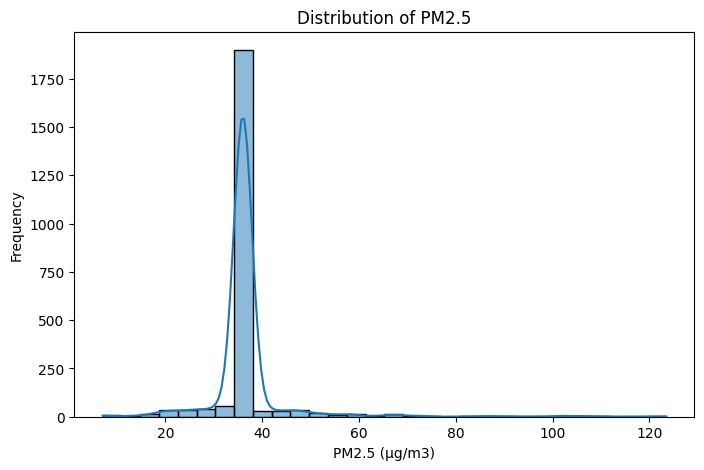

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["PM2.5 (μg/m3)"], bins=30, kde=True)
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5 (μg/m3)")
plt.ylabel("Frequency")
plt.show()

### Top 10 cities by average PM2.5

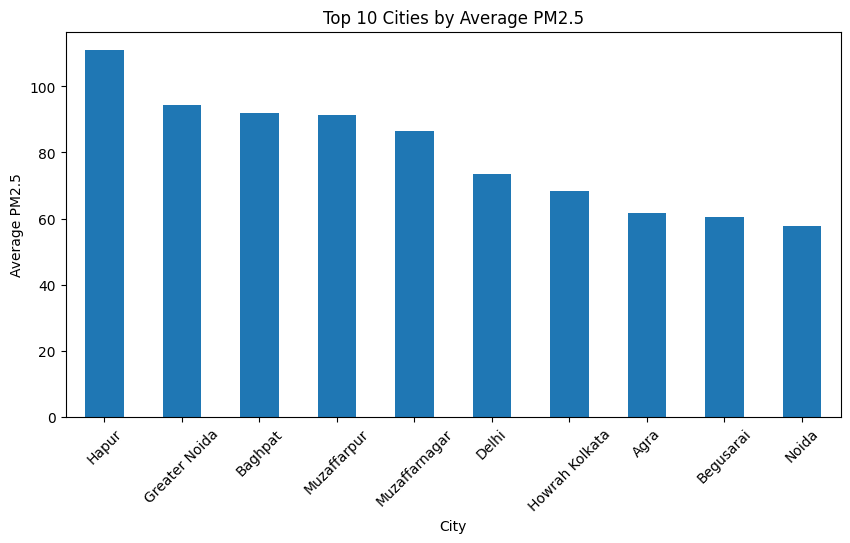

In [17]:
top_cities = (
    df.groupby("City or Locality")["PM2.5 (μg/m3)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Average PM2.5")
plt.ylabel("Average PM2.5")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()

### Correlation heatmap

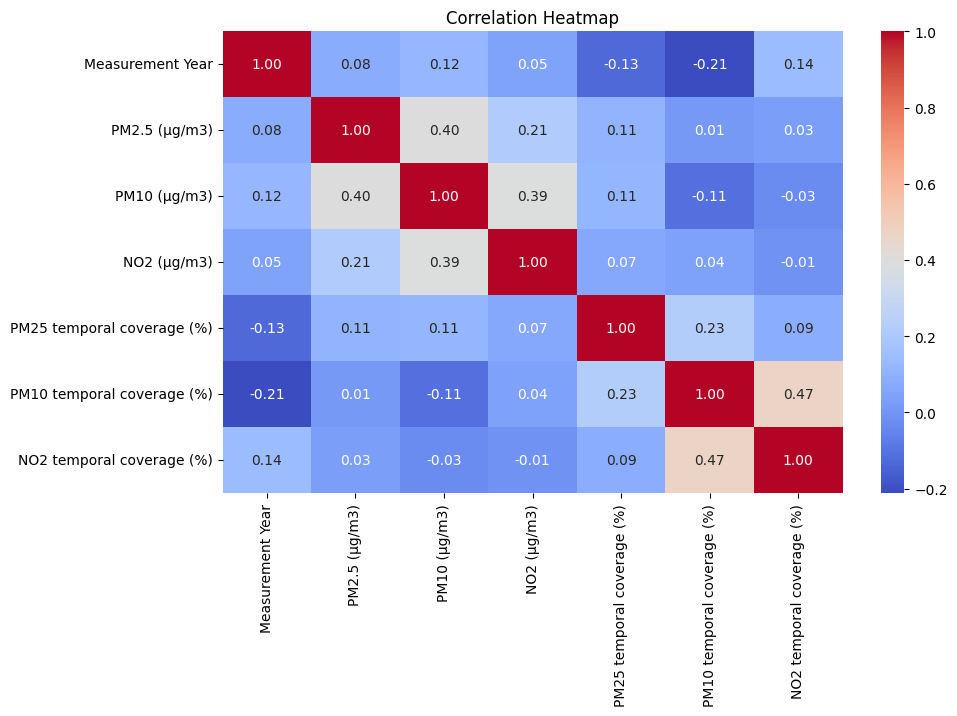

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 6) Create classification target

In [19]:
def categorize_pm25(x):
    if x <= 30:
        return "Good"
    elif x <= 60:
        return "Moderate"
    elif x <= 90:
        return "Poor"
    else:
        return "Very Poor"

df["Air_Quality_Category"] = df["PM2.5 (μg/m3)"].apply(categorize_pm25)

print(df["Air_Quality_Category"].value_counts())

Air_Quality_Category
Moderate     2086
Good          132
Poor           29
Very Poor      18
Name: count, dtype: int64


## 7) Prepare data for REGRESSION

In [20]:
target_reg = "PM2.5 (μg/m3)"

# Features for regression
X_reg = df.drop(columns=[target_reg, "Air_Quality_Category"])
y_reg = df[target_reg]

# One-hot encode categorical variables
X_reg = pd.get_dummies(X_reg, drop_first=True)

print("Regression feature shape:", X_reg.shape)

Regression feature shape: (2265, 413)


### Train-test split

In [21]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)

X_train_reg: (1812, 413)
X_test_reg : (453, 413)


### Scale data for models that need scaling

In [22]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

## 8) Regression models

In [76]:
regression_results = []

### 8.1 Linear Regression

In [77]:
lr = LinearRegression()
lr.fit(X_train_reg_scaled, y_train_reg)

y_train_pred_lr = lr.predict(X_train_reg_scaled)
y_test_pred_lr = lr.predict(X_test_reg_scaled)

train_mse_lr = mean_squared_error(y_train_reg, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test_reg, y_test_pred_lr)

train_rmse_lr = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_lr))

train_r2_lr = r2_score(y_train_reg, y_train_pred_lr)
test_r2_lr = r2_score(y_test_reg, y_test_pred_lr)

print("\n--- Linear Regression ---")
print("Train MSE:", train_mse_lr)
print("Test MSE :", test_mse_lr)
print("Train RMSE:", train_rmse_lr)
print("Test RMSE :", test_rmse_lr)
print("Train R2  :", train_r2_lr)
print("Test R2   :", test_r2_lr)

regression_results.append({
    "Model": "Linear Regression",
    "Train MSE": train_mse_lr,
    "Test MSE": test_mse_lr,
    "Train RMSE": train_rmse_lr,
    "Test RMSE": test_rmse_lr,
    "Train R2": train_r2_lr,
    "Test R2": test_r2_lr
})


--- Linear Regression ---
Train MSE: 36.38070694325998
Test MSE : 53.95847347327701
Train RMSE: 6.031642143169634
Test RMSE : 7.345643162669761
Train R2  : 0.5408868090160215
Test R2   : 0.2924373849616836


### 8.2 Random Forest Regressor

In [78]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

y_train_pred_rf = rf_reg.predict(X_train_reg)
y_test_pred_rf = rf_reg.predict(X_test_reg)

train_mse_rf = mean_squared_error(y_train_reg, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test_reg, y_test_pred_rf)

train_rmse_rf = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_rf))

train_r2_rf = r2_score(y_train_reg, y_train_pred_rf)
test_r2_rf = r2_score(y_test_reg, y_test_pred_rf)

print("\n--- Random Forest Regressor ---")
print("Train MSE:", train_mse_rf)
print("Test MSE :", test_mse_rf)
print("Train RMSE:", train_rmse_rf)
print("Test RMSE :", test_rmse_rf)
print("Train R2  :", train_r2_rf)
print("Test R2   :", test_r2_rf)

regression_results.append({
    "Model": "Random Forest Regressor",
    "Train MSE": train_mse_rf,
    "Test MSE": test_mse_rf,
    "Train RMSE": train_rmse_rf,
    "Test RMSE": test_rmse_rf,
    "Train R2": train_r2_rf,
    "Test R2": test_r2_rf
})


--- Random Forest Regressor ---
Train MSE: 3.4935121249779235
Test MSE : 20.055552310347682
Train RMSE: 1.8690939315555877
Test RMSE : 4.478342585192393
Train R2  : 0.9559129650245298
Test R2   : 0.7370096274911253


### 8.3 Gradient Boosting Regressor

In [79]:
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)

y_train_pred_gb = gb_reg.predict(X_train_reg)
y_test_pred_gb = gb_reg.predict(X_test_reg)

train_mse_gb = mean_squared_error(y_train_reg, y_train_pred_gb)
test_mse_gb = mean_squared_error(y_test_reg, y_test_pred_gb)

train_rmse_gb = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_gb))
test_rmse_gb = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_gb))

train_r2_gb = r2_score(y_train_reg, y_train_pred_gb)
test_r2_gb = r2_score(y_test_reg, y_test_pred_gb)

print("\n--- Gradient Boosting Regressor ---")
print("Train MSE:", train_mse_gb)
print("Test MSE :", test_mse_gb)
print("Train RMSE:", train_rmse_gb)
print("Test RMSE :", test_rmse_gb)
print("Train R2  :", train_r2_gb)
print("Test R2   :", test_r2_gb)

regression_results.append({
    "Model": "Gradient Boosting Regressor",
    "Train MSE": train_mse_gb,
    "Test MSE": test_mse_gb,
    "Train RMSE": train_rmse_gb,
    "Test RMSE": test_rmse_gb,
    "Train R2": train_r2_gb,
    "Test R2": test_r2_gb
})


--- Gradient Boosting Regressor ---
Train MSE: 10.748335228456682
Test MSE : 21.734605414309417
Train RMSE: 3.2784653770410146
Test RMSE : 4.662038761562308
Train R2  : 0.8643593569471173
Test R2   : 0.7149920438095606


### 8.4 ANN Regressor using TensorFlow

In [80]:
ann_reg = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_reg_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

ann_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop_reg = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_reg = ann_reg.fit(
    X_train_reg_scaled, y_train_reg,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_reg],
    verbose=0
)

y_train_pred_ann_reg = ann_reg.predict(X_train_reg_scaled).flatten()
y_test_pred_ann_reg = ann_reg.predict(X_test_reg_scaled).flatten()

train_mse_ann = mean_squared_error(y_train_reg, y_train_pred_ann_reg)
test_mse_ann = mean_squared_error(y_test_reg, y_test_pred_ann_reg)

train_rmse_ann_reg = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_ann_reg))
test_rmse_ann_reg = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_ann_reg))

train_r2_ann_reg = r2_score(y_train_reg, y_train_pred_ann_reg)
test_r2_ann_reg = r2_score(y_test_reg, y_test_pred_ann_reg)

print("\n--- ANN Regressor (TensorFlow) ---")
print("Train MSE:", train_mse_ann)
print("Test MSE :", test_mse_ann)
print("Train RMSE:", train_rmse_ann_reg)
print("Test RMSE :", test_rmse_ann_reg)
print("Train R2  :", train_r2_ann_reg)
print("Test R2   :", test_r2_ann_reg)

regression_results.append({
    "Model": "ANN Regressor (TensorFlow)",
    "Train MSE": train_mse_ann,
    "Test MSE": test_mse_ann,
    "Train RMSE": train_rmse_ann_reg,
    "Test RMSE": test_rmse_ann_reg,
    "Train R2": train_r2_ann_reg,
    "Test R2": test_r2_ann_reg
})

c:\Users\annaj\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- ANN Regressor (TensorFlow) ---
Train MSE: 30.001739664492934
Test MSE : 48.54290421700938
Train RMSE: 5.477384381663654
Test RMSE : 6.967273800921662
Train R2  : 0.6213873893677098
Test R2   : 0.36345226174064893


### Regression comparison table

In [81]:
regression_results_df = pd.DataFrame(regression_results)
display(regression_results_df.sort_values(by="Test R2", ascending=False).reset_index(drop=True))

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Random Forest Regressor,3.493512,20.055552,1.869094,4.478343,0.955913,0.737010
1,Gradient Boosting Regressor,10.748335,21.734605,3.278465,4.662039,0.864359,0.714992
2,ANN Regressor (TensorFlow),30.001740,48.542904,5.477384,6.967274,0.621387,0.363452
3,Linear Regression,36.380707,53.958473,6.031642,7.345643,0.540887,0.292437


## 9) Hyperparameter tuning for regression

### 9.1 Random Forest Regressor tuning

In [29]:
param_grid_rf_reg = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_reg,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_rf_reg.fit(X_train_reg, y_train_reg)

best_rf_reg = grid_rf_reg.best_estimator_

print("Best RF Regressor Params:", grid_rf_reg.best_params_)

y_train_pred_best_rf_reg = best_rf_reg.predict(X_train_reg)
y_test_pred_best_rf_reg = best_rf_reg.predict(X_test_reg)

print("\n--- Tuned Random Forest Regressor ---")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_reg, y_train_pred_best_rf_reg)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_test_pred_best_rf_reg)))
print("Train R2  :", r2_score(y_train_reg, y_train_pred_best_rf_reg))
print("Test R2   :", r2_score(y_test_reg, y_test_pred_best_rf_reg))

Best RF Regressor Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

--- Tuned Random Forest Regressor ---
Train RMSE: 1.8639639795659158
Test RMSE : 4.41250347537025
Train R2  : 0.9561546372073814
Test R2   : 0.7446855797480607


### 9.2 Gradient Boosting Regressor tuning

In [30]:
param_grid_gb_reg = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_gb_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb_reg,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_gb_reg.fit(X_train_reg, y_train_reg)

best_gb_reg = grid_gb_reg.best_estimator_

print("Best GB Regressor Params:", grid_gb_reg.best_params_)

y_train_pred_best_gb_reg = best_gb_reg.predict(X_train_reg)
y_test_pred_best_gb_reg = best_gb_reg.predict(X_test_reg)

print("\n--- Tuned Gradient Boosting Regressor ---")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_reg, y_train_pred_best_gb_reg)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_test_pred_best_gb_reg)))
print("Train R2  :", r2_score(y_train_reg, y_train_pred_best_gb_reg))
print("Test R2   :", r2_score(y_test_reg, y_test_pred_best_gb_reg))

Best GB Regressor Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

--- Tuned Gradient Boosting Regressor ---
Train RMSE: 1.3240392799406377
Test RMSE : 4.448424423197233
Train R2  : 0.9778766762033472
Test R2   : 0.7405117741803178


## 10) Prepare data for CLASSIFICATION

In [31]:
target_clf = "Air_Quality_Category"

X_clf = df.drop(columns=[target_clf, "PM2.5 (μg/m3)"])
y_clf = df[target_clf]

# One-hot encoding
X_clf = pd.get_dummies(X_clf, drop_first=True)

# Encode target labels
label_encoder = LabelEncoder()
y_clf_encoded = label_encoder.fit_transform(y_clf)

print("Classes:", label_encoder.classes_)
print("Feature shape:", X_clf.shape)

Classes: ['Good' 'Moderate' 'Poor' 'Very Poor']
Feature shape: (2265, 413)


### Train-test split

In [32]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_clf_encoded
)

print("X_train_clf:", X_train_clf.shape)
print("X_test_clf :", X_test_clf.shape)

X_train_clf: (1812, 413)
X_test_clf : (453, 413)


### Scale classification features

In [33]:
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

## 11) Classification models

In [54]:
classification_results = []

### 11.1 Logistic Regression

In [55]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_clf_scaled, y_train_clf)

y_train_pred_log = log_model.predict(X_train_clf_scaled)
y_test_pred_log = log_model.predict(X_test_clf_scaled)

train_acc_log = accuracy_score(y_train_clf, y_train_pred_log)
test_acc_log = accuracy_score(y_test_clf, y_test_pred_log)

train_prec_log = precision_score(y_train_clf, y_train_pred_log, average="weighted", zero_division=0)
test_prec_log = precision_score(y_test_clf, y_test_pred_log, average="weighted", zero_division=0)

train_rec_log = recall_score(y_train_clf, y_train_pred_log, average="weighted", zero_division=0)
test_rec_log = recall_score(y_test_clf, y_test_pred_log, average="weighted", zero_division=0)

train_f1_log = f1_score(y_train_clf, y_train_pred_log, average="weighted", zero_division=0)
test_f1_log = f1_score(y_test_clf, y_test_pred_log, average="weighted", zero_division=0)

print("\n--- Logistic Regression ---")
print("Train Accuracy :", train_acc_log)
print("Test Accuracy  :", test_acc_log)
print("Train Precision:", train_prec_log)
print("Test Precision :", test_prec_log)
print("Train Recall   :", train_rec_log)
print("Test Recall    :", test_rec_log)
print("Train F1       :", train_f1_log)
print("Test F1        :", test_f1_log)

classification_results.append({
    "Model": "Logistic Regression",
    "Train Accuracy": train_acc_log,
    "Test Accuracy": test_acc_log,
    "Train Precision": train_prec_log,
    "Test Precision": test_prec_log,
    "Train Recall": train_rec_log,
    "Test Recall": test_rec_log,
    "Train F1": train_f1_log,
    "Test F1": test_f1_log
})


--- Logistic Regression ---
Train Accuracy : 0.9740618101545254
Test Accuracy  : 0.9249448123620309
Train Precision: 0.9733687083937862
Test Precision : 0.9277409860191317
Train Recall   : 0.9740618101545254
Test Recall    : 0.9249448123620309
Train F1       : 0.9733975126441075
Test F1        : 0.9241478168630487


### Confusion matrix for Logistic Regression

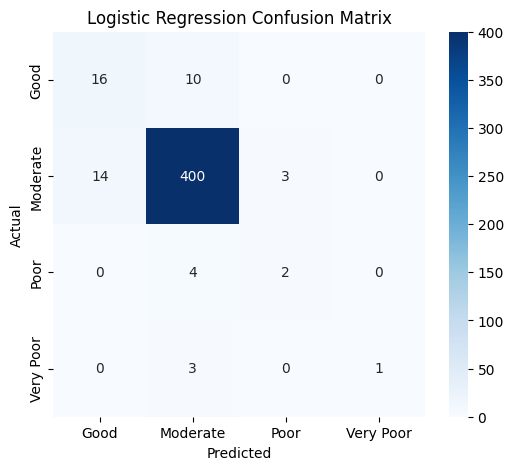

In [56]:
cm_log = confusion_matrix(y_test_clf, y_test_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 11.2 Random Forest Classifier

In [57]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)

y_train_pred_rf_clf = rf_clf.predict(X_train_clf)
y_test_pred_rf_clf = rf_clf.predict(X_test_clf)

train_acc_rf_clf = accuracy_score(y_train_clf, y_train_pred_rf_clf)
test_acc_rf_clf = accuracy_score(y_test_clf, y_test_pred_rf_clf)

train_prec_rf_clf = precision_score(y_train_clf, y_train_pred_rf_clf, average="weighted", zero_division=0)
test_prec_rf_clf = precision_score(y_test_clf, y_test_pred_rf_clf, average="weighted", zero_division=0)

train_rec_rf_clf = recall_score(y_train_clf, y_train_pred_rf_clf, average="weighted", zero_division=0)
test_rec_rf_clf = recall_score(y_test_clf, y_test_pred_rf_clf, average="weighted", zero_division=0)

train_f1_rf_clf = f1_score(y_train_clf, y_train_pred_rf_clf, average="weighted", zero_division=0)
test_f1_rf_clf = f1_score(y_test_clf, y_test_pred_rf_clf, average="weighted", zero_division=0)

print("\n--- Random Forest Classifier ---")
print("Train Accuracy :", train_acc_rf_clf)
print("Test Accuracy  :", test_acc_rf_clf)
print("Train Precision:", train_prec_rf_clf)
print("Test Precision :", test_prec_rf_clf)
print("Train Recall   :", train_rec_rf_clf)
print("Test Recall    :", test_rec_rf_clf)
print("Train F1       :", train_f1_rf_clf)
print("Test F1        :", test_f1_rf_clf)

classification_results.append({
    "Model": "Random Forest Classifier",
    "Train Accuracy": train_acc_rf_clf,
    "Test Accuracy": test_acc_rf_clf,
    "Train Precision": train_prec_rf_clf,
    "Test Precision": test_prec_rf_clf,
    "Train Recall": train_rec_rf_clf,
    "Test Recall": test_rec_rf_clf,
    "Train F1": train_f1_rf_clf,
    "Test F1": test_f1_rf_clf
})


--- Random Forest Classifier ---
Train Accuracy : 1.0
Test Accuracy  : 0.9492273730684326
Train Precision: 1.0
Test Precision : 0.9478006840089083
Train Recall   : 1.0
Test Recall    : 0.9492273730684326
Train F1       : 1.0
Test F1        : 0.9419269728183866


### Confusion matrix for Random Forest Classifier

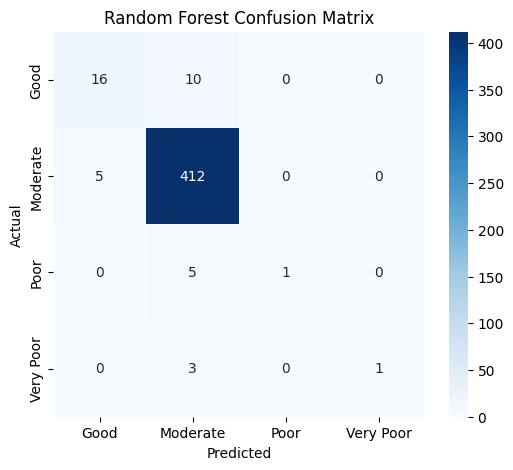

In [67]:
cm_rf = confusion_matrix(y_test_clf, y_test_pred_rf_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 11.3 Gradient Boosting Classifier

In [58]:
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train_clf, y_train_clf)

y_train_pred_gb_clf = gb_clf.predict(X_train_clf)
y_test_pred_gb_clf = gb_clf.predict(X_test_clf)

train_acc_gb_clf = accuracy_score(y_train_clf, y_train_pred_gb_clf)
test_acc_gb_clf = accuracy_score(y_test_clf, y_test_pred_gb_clf)

train_prec_gb_clf = precision_score(y_train_clf, y_train_pred_gb_clf, average="weighted", zero_division=0)
test_prec_gb_clf = precision_score(y_test_clf, y_test_pred_gb_clf, average="weighted", zero_division=0)

train_rec_gb_clf = recall_score(y_train_clf, y_train_pred_gb_clf, average="weighted", zero_division=0)
test_rec_gb_clf = recall_score(y_test_clf, y_test_pred_gb_clf, average="weighted", zero_division=0)

train_f1_gb_clf = f1_score(y_train_clf, y_train_pred_gb_clf, average="weighted", zero_division=0)
test_f1_gb_clf = f1_score(y_test_clf, y_test_pred_gb_clf, average="weighted", zero_division=0)

print("\n--- Gradient Boosting Classifier ---")
print("Train Accuracy :", train_acc_gb_clf)
print("Test Accuracy  :", test_acc_gb_clf)
print("Train Precision:", train_prec_gb_clf)
print("Test Precision :", test_prec_gb_clf)
print("Train Recall   :", train_rec_gb_clf)
print("Test Recall    :", test_rec_gb_clf)
print("Train F1 Score :", train_f1_gb_clf)
print("Test F1 Score  :", test_f1_gb_clf)

classification_results.append({
    "Model": "Gradient Boosting Classifier",
    "Train Accuracy": train_acc_gb_clf,
    "Test Accuracy": test_acc_gb_clf,
    "Train Precision": train_prec_gb_clf,
    "Test Precision": test_prec_gb_clf,
    "Train Recall": train_rec_gb_clf,
    "Test Recall": test_rec_gb_clf,
    "Train F1": train_f1_gb_clf,
    "Test F1": test_f1_gb_clf
})


--- Gradient Boosting Classifier ---
Train Accuracy : 0.9955849889624724
Test Accuracy  : 0.9448123620309051
Train Precision: 0.995606050434327
Test Precision : 0.9430745385374101
Train Recall   : 0.9955849889624724
Test Recall    : 0.9448123620309051
Train F1 Score : 0.9955036980756076
Test F1 Score  : 0.9413224009250499


### Confusion matrix for Gradient Boosting Classifier

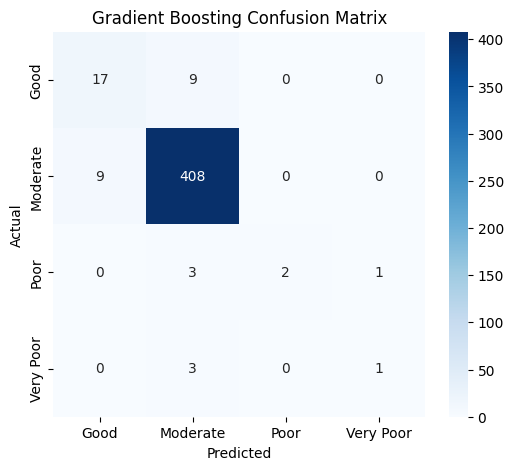

In [69]:
cm_gb = confusion_matrix(y_test_clf, y_test_pred_gb_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 11.4 ANN Classifier using TensorFlow

In [59]:
num_classes = len(np.unique(y_train_clf))

ann_clf = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_clf_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

ann_clf.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_clf = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_clf = ann_clf.fit(
    X_train_clf_scaled, y_train_clf,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_clf],
    verbose=0
)

# Predictions
y_train_pred_ann_probs = ann_clf.predict(X_train_clf_scaled)
y_test_pred_ann_probs = ann_clf.predict(X_test_clf_scaled)

y_train_pred_ann_clf = np.argmax(y_train_pred_ann_probs, axis=1)
y_test_pred_ann_clf = np.argmax(y_test_pred_ann_probs, axis=1)

train_acc_ann_clf = accuracy_score(y_train_clf, y_train_pred_ann_clf)
test_acc_ann_clf = accuracy_score(y_test_clf, y_test_pred_ann_clf)

train_prec_ann_clf = precision_score(y_train_clf, y_train_pred_ann_clf, average="weighted", zero_division=0)
test_prec_ann_clf = precision_score(y_test_clf, y_test_pred_ann_clf, average="weighted", zero_division=0)

train_rec_ann_clf = recall_score(y_train_clf, y_train_pred_ann_clf, average="weighted", zero_division=0)
test_rec_ann_clf = recall_score(y_test_clf, y_test_pred_ann_clf, average="weighted", zero_division=0)

train_f1_ann_clf = f1_score(y_train_clf, y_train_pred_ann_clf, average="weighted", zero_division=0)
test_f1_ann_clf = f1_score(y_test_clf, y_test_pred_ann_clf, average="weighted", zero_division=0)

print("\n--- ANN Classifier (TensorFlow) ---")
print("Train Accuracy :", train_acc_ann_clf)
print("Test Accuracy  :", test_acc_ann_clf)
print("Train Precision:", train_prec_ann_clf)
print("Test Precision :", test_prec_ann_clf)
print("Train Recall   :", train_rec_ann_clf)
print("Test Recall    :", test_rec_ann_clf)
print("Train F1 Score :", train_f1_ann_clf)
print("Test F1 Score  :", test_f1_ann_clf)

classification_results.append({
    "Model": "ANN Classifier (TensorFlow)",
    "Train Accuracy": train_acc_ann_clf,
    "Test Accuracy": test_acc_ann_clf,
    "Train Precision": train_prec_ann_clf,
    "Test Precision": test_prec_ann_clf,
    "Train Recall": train_rec_ann_clf,
    "Test Recall": test_rec_ann_clf,
    "Train F1": train_f1_ann_clf,
    "Test F1": test_f1_ann_clf
})

c:\Users\annaj\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- ANN Classifier (TensorFlow) ---
Train Accuracy : 0.9337748344370861
Test Accuracy  : 0.9315673289183223
Train Precision: 0.9175102048409215
Test Precision : 0.9069879979691172
Train Recall   : 0.9337748344370861
Test Recall    : 0.9315673289183223
Train F1 Score : 0.9128320743878562
Test F1 Score  : 0.9113763540222803


### Confusion matrix for ANN classifier

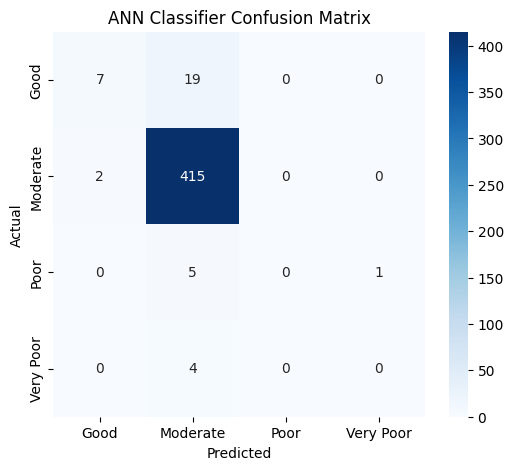

In [70]:
cm_ann = confusion_matrix(y_test_clf, y_test_pred_ann_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ann,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("ANN Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 12) Classification comparison table

In [62]:
classification_results_df = pd.DataFrame(classification_results)
display(classification_results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True))

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,Random Forest Classifier,1.000000,0.949227,1.000000,0.947801,1.000000,0.949227,1.000000,0.941927
1,Gradient Boosting Classifier,0.995585,0.944812,0.995606,0.943075,0.995585,0.944812,0.995504,0.941322
2,ANN Classifier (TensorFlow),0.933775,0.931567,0.917510,0.906988,0.933775,0.931567,0.912832,0.911376
3,Logistic Regression,0.974062,0.924945,0.973369,0.927741,0.974062,0.924945,0.973398,0.924148


## 13) Hyperparameter tuning for classification

### 13.1 Random Forest Classifier tuning

In [63]:
param_grid_rf_clf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf_clf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf_clf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf_clf.fit(X_train_clf, y_train_clf)

best_rf_clf = grid_rf_clf.best_estimator_

print("Best RF Classifier Params:", grid_rf_clf.best_params_)

y_train_pred_best_rf_clf = best_rf_clf.predict(X_train_clf)
y_test_pred_best_rf_clf = best_rf_clf.predict(X_test_clf)

# Train metrics
train_acc_best_rf_clf = accuracy_score(y_train_clf, y_train_pred_best_rf_clf)
train_prec_best_rf_clf = precision_score(y_train_clf, y_train_pred_best_rf_clf, average="weighted", zero_division=0)
train_rec_best_rf_clf = recall_score(y_train_clf, y_train_pred_best_rf_clf, average="weighted", zero_division=0)
train_f1_best_rf_clf = f1_score(y_train_clf, y_train_pred_best_rf_clf, average="weighted", zero_division=0)

# Test metrics
test_acc_best_rf_clf = accuracy_score(y_test_clf, y_test_pred_best_rf_clf)
test_prec_best_rf_clf = precision_score(y_test_clf, y_test_pred_best_rf_clf, average="weighted", zero_division=0)
test_rec_best_rf_clf = recall_score(y_test_clf, y_test_pred_best_rf_clf, average="weighted", zero_division=0)
test_f1_best_rf_clf = f1_score(y_test_clf, y_test_pred_best_rf_clf, average="weighted", zero_division=0)

print("\n--- Tuned Random Forest Classifier ---")
print("Train Accuracy :", train_acc_best_rf_clf)
print("Test Accuracy  :", test_acc_best_rf_clf)
print("Train Precision:", train_prec_best_rf_clf)
print("Test Precision :", test_prec_best_rf_clf)
print("Train Recall   :", train_rec_best_rf_clf)
print("Test Recall    :", test_rec_best_rf_clf)
print("Train F1 Score :", train_f1_best_rf_clf)
print("Test F1 Score  :", test_f1_best_rf_clf)

Best RF Classifier Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

--- Tuned Random Forest Classifier ---
Train Accuracy : 0.9994481236203091
Test Accuracy  : 0.9514348785871964
Train Precision: 0.9994484540852071
Test Precision : 0.9500413801072994
Train Recall   : 0.9994481236203091
Test Recall    : 0.9514348785871964
Train F1 Score : 0.9994468984973434
Test F1 Score  : 0.9431536804968828


### 13.2 Gradient Boosting Classifier tuning

In [64]:
param_grid_gb_clf = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_gb_clf = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb_clf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb_clf.fit(X_train_clf, y_train_clf)

best_gb_clf = grid_gb_clf.best_estimator_

print("Best GB Classifier Params:", grid_gb_clf.best_params_)

y_train_pred_best_gb_clf = best_gb_clf.predict(X_train_clf)
y_test_pred_best_gb_clf = best_gb_clf.predict(X_test_clf)

# Train metrics
train_acc_best_gb_clf = accuracy_score(y_train_clf, y_train_pred_best_gb_clf)
train_prec_best_gb_clf = precision_score(y_train_clf, y_train_pred_best_gb_clf, average="weighted", zero_division=0)
train_rec_best_gb_clf = recall_score(y_train_clf, y_train_pred_best_gb_clf, average="weighted", zero_division=0)
train_f1_best_gb_clf = f1_score(y_train_clf, y_train_pred_best_gb_clf, average="weighted", zero_division=0)

# Test metrics
test_acc_best_gb_clf = accuracy_score(y_test_clf, y_test_pred_best_gb_clf)
test_prec_best_gb_clf = precision_score(y_test_clf, y_test_pred_best_gb_clf, average="weighted", zero_division=0)
test_rec_best_gb_clf = recall_score(y_test_clf, y_test_pred_best_gb_clf, average="weighted", zero_division=0)
test_f1_best_gb_clf = f1_score(y_test_clf, y_test_pred_best_gb_clf, average="weighted", zero_division=0)

print("\n--- Tuned Gradient Boosting Classifier ---")
print("Train Accuracy :", train_acc_best_gb_clf)
print("Test Accuracy  :", test_acc_best_gb_clf)
print("Train Precision:", train_prec_best_gb_clf)
print("Test Precision :", test_prec_best_gb_clf)
print("Train Recall   :", train_rec_best_gb_clf)
print("Test Recall    :", test_rec_best_gb_clf)
print("Train F1 Score :", train_f1_best_gb_clf)
print("Test F1 Score  :", test_f1_best_gb_clf)

Best GB Classifier Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

--- Tuned Gradient Boosting Classifier ---
Train Accuracy : 0.9718543046357616
Test Accuracy  : 0.9470198675496688
Train Precision: 0.9708766720280765
Test Precision : 0.9461243006094938
Train Recall   : 0.9718543046357616
Test Recall    : 0.9470198675496688
Train F1 Score : 0.9695611491354096
Test F1 Score  : 0.9424482399890105


## 14) Final best-model summary

In [82]:
print("\n=== REGRESSION RESULTS ===")
display(
    regression_results_df
    .sort_values(by="Test R2", ascending=False)
    .reset_index(drop=True)
)

print("\n=== CLASSIFICATION RESULTS ===")
display(
    classification_results_df
    .sort_values(by="Test Accuracy", ascending=False)
    .reset_index(drop=True)
)


=== REGRESSION RESULTS ===


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Random Forest Regressor,3.493512,20.055552,1.869094,4.478343,0.955913,0.737010
1,Gradient Boosting Regressor,10.748335,21.734605,3.278465,4.662039,0.864359,0.714992
2,ANN Regressor (TensorFlow),30.001740,48.542904,5.477384,6.967274,0.621387,0.363452
3,Linear Regression,36.380707,53.958473,6.031642,7.345643,0.540887,0.292437



=== CLASSIFICATION RESULTS ===


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,Random Forest Classifier,1.000000,0.949227,1.000000,0.947801,1.000000,0.949227,1.000000,0.941927
1,Gradient Boosting Classifier,0.995585,0.944812,0.995606,0.943075,0.995585,0.944812,0.995504,0.941322
2,ANN Classifier (TensorFlow),0.933775,0.931567,0.917510,0.906988,0.933775,0.931567,0.912832,0.911376
3,Logistic Regression,0.974062,0.924945,0.973369,0.927741,0.974062,0.924945,0.973398,0.924148
